# Case Study
A process running is observed to have peaks in energy demand that amplifies across multiple production lines. The goal of this tool is to stagger the process such that the energy demand peaks do not coincide and amplify beyond utilities' capacity.

This peaks need to be minimized to reduce energy costs especially from over-demand which is costly.

## Technical Approach

Multi Stream Energy data is represented in a 2D Vector;
horizontal x-dimension representing time-blocks, 
vertical y-dimension representing individual production streams / lines.

Agglomeration of said data will reduce 2D Vector into 1D Vector along x-dimension by summation.

The cost function is generated by reducing the 1D Vector into a 0D Vector by identifying the maximum energy. 

Optimizer using Simulated Annealing Algorithm will search for the best combination of staggering that will yield the lowest maximum energy.

## Optimization Strategy
Lock first batch to prevent staggering of said batch running, to be used as baseline for starting batches.
No staggering for inactive stream.
To start batches at their designated start times, if unavailable due to batchs staggering, to start at the end of prior batch.

## Future Improvment
Batch Staggering to use real time instead of time-block abstraction. - NOTE Not Recommended, as this may require per second data which does not contribute much to improving accuracy or reliability while demanding significantly larger datasets and computation

Optimizer function can use direct Energy Data or further convert data based on Energy-Time Cost 
(requiring additional 1D Vector to indicate cost per energy unit at the specific time as for example electricity may have different tariff at peak or off-peak hours).

# Lesson Learnt
Prior tested Optimzers 
- Scipy's Brute Force > Too computationally intensive
- Scipy's Minimize function > Not suitable for integer problems

 If receive this "RuntimeWarning: overflow encountered in exp:", no issue. 
 It just meant that the exp is returning 0 due to very small number.

## Data Ingestion
### Observed Process Energy Demand 

In [1]:
import pandas as pd

df_pdt_E_d = pd.read_csv(r"data\Product Energy Demand.csv")
df_pdt_E_d

,Time Block,Alpha,Beta,Gamma,Delta,Echo,Foxtrot
0,1,0.0,0.0,0.0,0.0,0.0,0
1,2,100.0,0.0,63.0,0.0,0.0,0
2,3,300.0,0.0,188.0,0.0,0.0,0
3,4,400.0,50.0,313.0,0.0,0.0,0
4,5,450.0,150.0,344.0,50.0,25.0,0
...,...,...,...,...,...,...,...
64,65,NaN,NaN,NaN,0.0,0.0,0
65,66,NaN,NaN,NaN,0.0,0.0,0
66,67,NaN,NaN,NaN,0.0,NaN,0
67,68,NaN,NaN,NaN,NaN,NaN,0


### Production Plan

In [2]:
import pandas as pd

df_plan = pd.read_csv(r"data\Production Plan.csv", header=[0, 1])
df_plan

Stream 1                 Stream 2                 Stream 3                  \
     Grade Start Date Time    Grade Start Date Time    Grade Start Date Time   
0    Gamma  01/11/23 00:15     Beta  01/11/23 01:15     Beta  01/11/23 00:15   
1    Delta  02/11/23 01:00     Beta  02/11/23 03:00  Foxtrot  02/11/23 01:00   
2    Alpha  03/11/23 12:00      NaN  03/11/23 12:00      NaN  03/11/23 12:00   

  Stream 4                  
     Grade Start Date Time  
0     Echo  01/11/23 02:15  
1      NaN  02/11/23 01:28  
2     Echo  03/11/23 12:50

## Data Transformation

In [3]:
from data_processing.GEIST import GEIST

dict_pdt_E_d = GEIST(df_pdt_E_d)
dict_pdt_E_d

{'Alpha': [0.0,
  100.0,
  300.0,
  400.0,
  450.0,
  500.0,
  550.0,
  650.0,
  700.0,
  820.0,
  870.0,
  900.0,
  1050.0,
  1200.0,
  1400.0,
  1450.0,
  1600.0,
  1750.0,
  1800.0,
  1850.0,
  1900.0,
  2050.0,
  2600.0,
  3300.0,
  2850.0,
  2750.0,
  2550.0,
  2400.0,
  2350.0,
  2350.0,
  2300.0,
  2150.0,
  2000.0,
  1950.0,
  1850.0,
  1450.0,
  1000.0,
  0.0,
  0.0,
  0.0,
  20.0,
  200.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0],
 'Beta': [0.0,
  0.0,
  0.0,
  50.0,
  150.0,
  250.0,
  350.0,
  500.0,
  650.0,
  800.0,
  950.0,
  1050.0,
  1150.0,
  1300.0,
  1400.0,
  1480.0,
  1560.0,
  1620.0,
  1680.0,
  1740.0,
  1800.0,
  1860.0,
  1950.0,
  2400.0,
  2700.0,
  2500.0,
  2450.0,
  2400.0,
  2350.0,
  2320.0,
  2300.0,
  2280.0,
  2150.0,
  1800.0,
  1500.0,
  1400.0,
  1350.0,
  1300.0,
  1250.0,
  1200.0,
  1150.0,
  1050.0,
  1000.0,
  1100.0,
  1000.0,
  500.0,
  300.0,
  300.0,
  320.0,
  350.0,
  380.0,
  330.0,
  300.0,


## Constants Declaration

In [4]:
# x-dimension discretization
days = 5 # Forecast days

hours_in_day = 24
mins_in_hr = 60
mins_in_time_block = 15

TIME_BLOCKS = int((days * hours_in_day * mins_in_hr)/mins_in_time_block)

In [5]:
stagger_upper_lim = 30  # User-Defined

# NOTE to account for maximum upper limit for each stream to avoid truncating the product energy data.
# Best Practise seems to be about 50% of batches length to avoid being too slack

## Process Optimization

In [6]:
import numpy as np
from data_processing.BEAMS import StreamData, BEAMS

StreamDataObject = StreamData(dict_pdt_E_d, df_plan, TIME_BLOCKS)

stagger_limit = 50

stagger_limits = np.zeros(len(StreamDataObject.pd_prod_plan.columns.values)) + stagger_limit
stagger_limits = stagger_limits.astype(int)



In [7]:
benchmark_stagger = BEAMS(StreamDataObject=StreamDataObject, stagger_limits=stagger_limits, flag_optimizer=False)


row > 0
Zeroth Row
ls_low_bounds > [0, 4, 0, 8]
bounds >
[[ 0  0]
 [ 4 54]
 [ 0 50]
 [ 8 58]]
best > [0 4 0 8]

row > 1
Non-Zeroth Row
ls_low_bounds > [99, 107, 99, 0]
bounds >
[[ 99 149]
 [107 157]
 [ 99 149]
 [ 74  74]]
best > [ 99 107  99  74]

row > 2
Non-Zeroth Row
ls_low_bounds > [239, 0, 0, 242]
bounds >
[[239 289]
 [168 168]
 [168 168]
 [242 292]]
best > [239 168 168 242]


In [8]:
optimized_stagger = BEAMS(StreamDataObject=StreamDataObject, stagger_limits=stagger_limits, flag_optimizer=True)


row > 0
Zeroth Row
ls_low_bounds > [0, 4, 0, 8]
bounds >
[[ 0  0]
 [ 4 54]
 [ 0 50]
 [ 8 58]]
initial guess > [0, 51, 45, 58]
best > [0, 23, 40, 58]

row > 1
Non-Zeroth Row
ls_low_bounds > [99, 107, 99, 0]
bounds >
[[ 99 149]
 [107 157]
 [101 151]
 [124 124]]
initial guess > [123, 138, 123, 124]
best > [148, 112, 126, 124]

row > 2
Non-Zeroth Row
ls_low_bounds > [239, 0, 0, 242]
bounds >
[[239 289]
 [173 173]
 [195 195]
 [242 292]]
initial guess > [284, 173, 195, 255]
best > [284, 173, 195, 255]


## Results Visualization

In [9]:
from visualization.visualizations import configure_stream_visualization, visualize_stream_energy

benchmark_energy = configure_stream_visualization(StreamDataObject=StreamDataObject, shift_array=benchmark_stagger)
optimized_energy = configure_stream_visualization(StreamDataObject=StreamDataObject, shift_array=optimized_stagger)

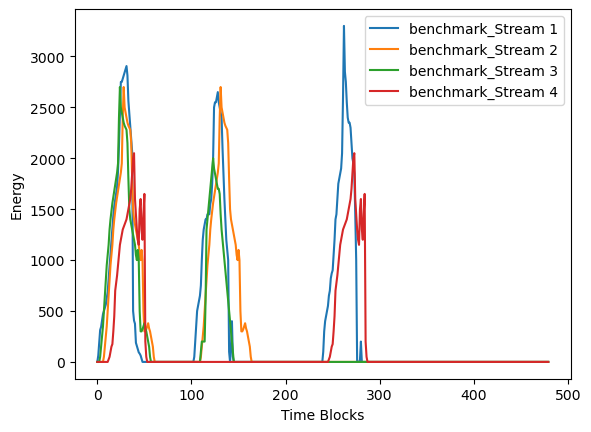

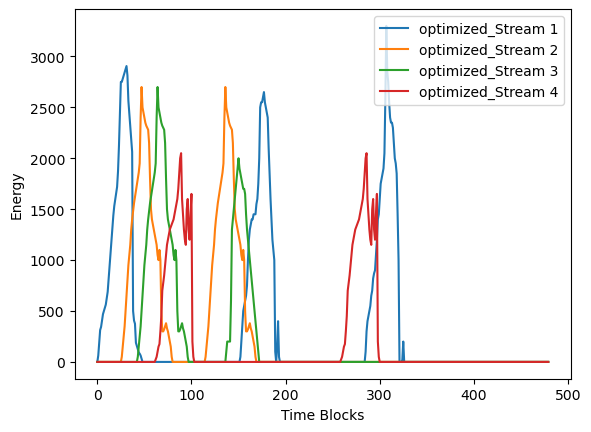

In [10]:
import matplotlib.pyplot as plt

plt.figure()
for stream in benchmark_energy:
    benchmark_stream_name = "benchmark_" + stream

    visualize_stream_energy(
        stream_name=benchmark_stream_name, 
        num_time_blocks=TIME_BLOCKS,
        stream_energy=benchmark_energy[stream],
        figure_num=1
        )
    
plt.figure()
for stream in optimized_energy:
    optimized_stream_name = "optimized_" + stream
        
    visualize_stream_energy(
        stream_name=optimized_stream_name,
        num_time_blocks=TIME_BLOCKS,
        stream_energy=optimized_energy[stream],
        figure_num=2
        )

In [11]:
from data_processing.BEAMS import accumulate_multi_stream_data

accumulated_benchmark = accumulate_multi_stream_data(stream_holding_dict=benchmark_energy)
accumulated_optimized = accumulate_multi_stream_data(stream_holding_dict=optimized_energy)

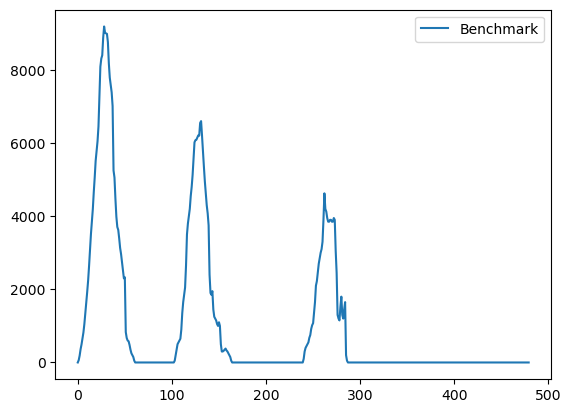

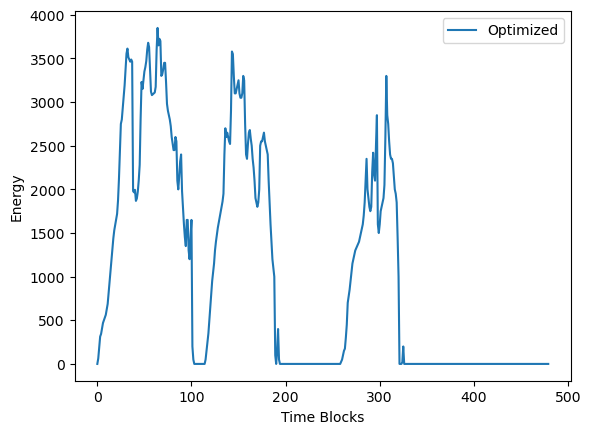

In [12]:
plt.figure()
visualize_stream_energy(
    stream_name="Benchmark",
    num_time_blocks=TIME_BLOCKS,
    stream_energy=accumulated_benchmark,
    figure_num=3)

visualize_stream_energy(stream_name="Optimized",
    num_time_blocks=TIME_BLOCKS,
    stream_energy=accumulated_optimized,
    figure_num=3)